#Notebook 2: Training Comparison
A CNN Portfolio from Yonathan Hary Hutagalung

This notebook trains and compares three CNN architectures on the EuroSAT RGB dataset:
- `microsoft/resnet-18` — Lightweight CNN baseline
- `google/efficientnet-b0` — Efficient CNN with compound scaling
- `google/vit-base-patch16-224` — Vision Transformer (attention-based)

**Outputs saved:**
- Model checkpoints in `./models/<model_name>/`
- `results/comparison_results.csv` — accuracy + F1 per model
- `results/model_comparison_chart.png` — bar chart visualization

---
📋 **Table of Contents**:

0. Install & Imports
1. Configuration
2. Load Dataset
3. Define Training Pipeline
4. Train All Models
5. Compare Results
6. Save Best Model

# 0. Install and Imports

In [1]:
!pip -q install transformers datasets evaluate accelerate torchvision scikit-learn matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [2]:
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
    DefaultDataCollator
)
import evaluate
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

#Check if GPU from Colabs working properly
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cuda
   GPU: Tesla T4


# 1. Configuration

In [3]:
CONFIG = {
    'dataset_name'  : 'blanchon/EuroSAT_RGB',
    'test_size'     : 0.2,
    'seed'          : 42,
    'batch_size'    : 32,
    'num_epochs'    : 5,
    'learning_rate' : 5e-5,
    'weight_decay'  : 0.01,
    'output_dir'    : './models',
    'results_dir'   : './results',
}

# Models to compare
MODELS = {
    'ResNet-18'      : 'microsoft/resnet-18',
    'EfficientNet-B0': 'google/efficientnet-b0',
    'ViT-Base'       : 'google/vit-base-patch16-224-in21k',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(CONFIG['results_dir'], exist_ok=True)

# 2. Load Dataset

In [4]:
print('Loading dataset...')
dataset = load_dataset(CONFIG['dataset_name'])

LABELS      = dataset['train'].features['label'].names
NUM_CLASSES = len(LABELS)
LABEL2ID    = {lbl: str(i) for i, lbl in enumerate(LABELS)}
ID2LABEL    = {str(i): lbl for i, lbl in enumerate(LABELS)}

print(f'\n📦 Dataset loaded!')
print(f'   Classes ({NUM_CLASSES}): {LABELS}')
print(f'   Total train samples : {len(dataset["train"]):,}')

Loading dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]


📦 Dataset loaded!
   Classes (10): ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']
   Total train samples : 16,200


# 3. Training Pipeline

## 3.1 Train val split

In [5]:
split = dataset['train'].train_test_split(
    test_size=CONFIG['test_size'],
    seed=CONFIG['seed']
)
TRAIN_DS_RAW = split['train']
VAL_DS_RAW   = split['test']
print(f'   Train split : {len(TRAIN_DS_RAW):,}')
print(f'   Val split   : {len(VAL_DS_RAW):,}')

   Train split : 12,960
   Val split   : 3,240


## 3.2 Metrics using Accuracy and Macro F1

In [6]:
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(
        predictions=predictions, references=labels
    )['accuracy']
    f1  = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'macro_f1': f1}

## 3.3 Full pipeline

In [7]:
def train_model(model_name, checkpoint):
    print(f'  🚀 Training: {model_name}')
    print(f'  Checkpoint : {checkpoint}')

    # Step A: Image Processor
    image_processor = AutoImageProcessor.from_pretrained(checkpoint)

    def transform(batch):
        images = [img.convert('RGB') for img in batch['image']]
        inputs = image_processor(images, return_tensors='pt')
        inputs['labels'] = batch['label']
        return inputs

    train_ds = TRAIN_DS_RAW.with_transform(transform)
    val_ds   = VAL_DS_RAW.with_transform(transform)

    # Step B: Model
    model = AutoModelForImageClassification.from_pretrained(
        checkpoint,
        num_labels          = NUM_CLASSES,
        id2label            = {int(k): v for k, v in ID2LABEL.items()},
        label2id            = {k: int(v) for k, v in LABEL2ID.items()},
        ignore_mismatched_sizes=True
    )

    # Step C: Training Arguments
    model_output = os.path.join(CONFIG['output_dir'], model_name.replace(' ', '_'))
    args = TrainingArguments(
        output_dir                  = model_output,
        remove_unused_columns       = False,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        logging_strategy            = 'steps',
        logging_steps               = 100,
        per_device_train_batch_size = CONFIG['batch_size'],
        per_device_eval_batch_size  = CONFIG['batch_size'],
        num_train_epochs            = CONFIG['num_epochs'],
        learning_rate               = CONFIG['learning_rate'],
        weight_decay                = CONFIG['weight_decay'],
        load_best_model_at_end      = True,
        metric_for_best_model       = 'accuracy',
        push_to_hub                 = False,
        report_to                   = 'none',
        fp16                        = (DEVICE == 'cuda'),
    )

    # Step D: Trainer
    trainer = Trainer(
        model             = model,
        args              = args,
        train_dataset     = train_ds,
        eval_dataset      = val_ds,
        processing_class  = image_processor,
        data_collator     = DefaultDataCollator(),
        compute_metrics   = compute_metrics,
    )

    #Step E: Train
    start = time.time()
    trainer.train()
    elapsed = (time.time() - start) / 60

    # Step F: Evaluate
    metrics = trainer.evaluate()

    # Step G: Save best model
    best_path = os.path.join(model_output, 'best')
    trainer.save_model(best_path)
    image_processor.save_pretrained(best_path)

    result = {
        'Model'          : model_name,
        'Checkpoint'     : checkpoint,
        'Val Accuracy'   : round(metrics.get('eval_accuracy', 0) * 100, 2),
        'Macro F1'       : round(metrics.get('eval_macro_f1', 0) * 100, 2),
        'Train Time (min)': round(elapsed, 1),
        'Saved Path'     : best_path,
    }

    print(f'\n Done — Accuracy: {result["Val Accuracy"]}% | '
          f'Macro F1: {result["Macro F1"]}% | Time: {elapsed:.1f} min')
    return result, trainer

# 4. Train Models

In [8]:
all_results  = []
all_trainers = {}

for model_name, checkpoint in MODELS.items():
    result, trainer = train_model(model_name, checkpoint)
    all_results.append(result)
    all_trainers[model_name] = trainer

df_results = pd.DataFrame(all_results)

  🚀 Training: ResNet-18
  Checkpoint : microsoft/resnet-18


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Done — Accuracy: 98.89% | Macro F1: 98.84% | Time: 15.2 min


In [9]:
print(df_results[['Model','Val Accuracy','Macro F1','Train Time (min)']].to_string(index=False))

          Model  Val Accuracy  Macro F1  Train Time (min)
      ResNet-18         98.18     98.08               3.6
EfficientNet-B0         97.16     97.08               5.9
       ViT-Base         98.89     98.84              15.2


# 6. Compare Models

In [10]:
csv_path = os.path.join(CONFIG['results_dir'], 'comparison_results.csv')
df_results.to_csv(csv_path, index=False)
print(f'✅ Results saved to: {csv_path}')
df_results

✅ Results saved to: ./results/comparison_results.csv


,Model,Checkpoint,Val Accuracy,Macro F1,Train Time (min),Saved Path
0,ResNet-18,microsoft/resnet-18,98.18,98.08,3.6,./models/ResNet-18/best
1,EfficientNet-B0,google/efficientnet-b0,97.16,97.08,5.9,./models/EfficientNet-B0/best
2,ViT-Base,google/vit-base-patch16-224-in21k,98.89,98.84,15.2,./models/ViT-Base/best


## 6.1 Model Comparision Chart

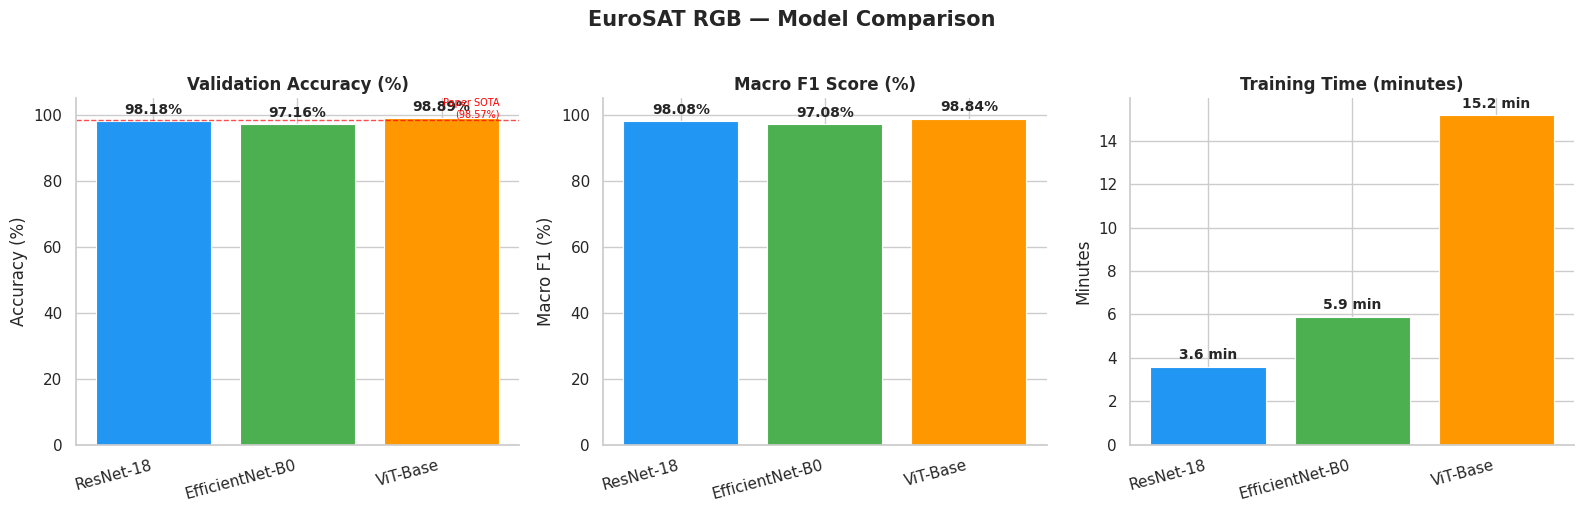

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EuroSAT RGB — Model Comparison', fontsize=15, fontweight='bold', y=1.02)

palette = ['#2196F3', '#4CAF50', '#FF9800']
models  = df_results['Model'].tolist()

# Chart 1: Validation Accuracy
bars = axes[0].bar(models, df_results['Val Accuracy'], color=palette, edgecolor='white', linewidth=0.8)
axes[0].bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')
axes[0].set_title('Validation Accuracy (%)', fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Accuracy (%)')
axes[0].axhline(y=98.57, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0].text(2.4, 99.1, 'Paper SOTA\n(98.57%)', color='red', fontsize=7, ha='right')

# Chart 2: Macro F1 Score
bars2 = axes[1].bar(models, df_results['Macro F1'], color=palette, edgecolor='white', linewidth=0.8)
axes[1].bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')
axes[1].set_title('Macro F1 Score (%)', fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('Macro F1 (%)')

# Chart 3: Training Time
bars3 = axes[2].bar(models, df_results['Train Time (min)'], color=palette, edgecolor='white', linewidth=0.8)
axes[2].bar_label(bars3, fmt='%.1f min', padding=3, fontsize=10, fontweight='bold')
axes[2].set_title('Training Time (minutes)', fontweight='bold')
axes[2].set_ylabel('Minutes')

for ax in axes:
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
chart_path = os.path.join(CONFIG['results_dir'], 'model_comparison_chart.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

# 6.2 Training curves (Accuracy per epoch)

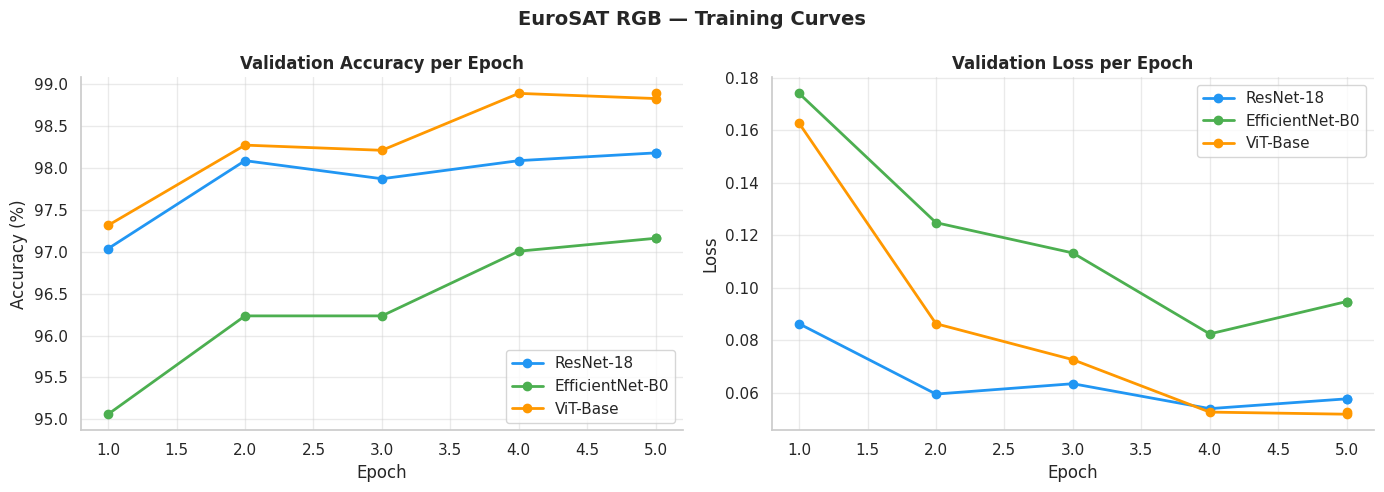

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EuroSAT RGB — Training Curves', fontsize=14, fontweight='bold')

for (model_name, trainer), color in zip(all_trainers.items(), palette):
    log_history = trainer.state.log_history

    # Extract epoch-level eval metrics
    eval_logs = [l for l in log_history if 'eval_accuracy' in l]
    epochs    = [l['epoch'] for l in eval_logs]
    accs      = [l['eval_accuracy'] * 100 for l in eval_logs]
    losses    = [l['eval_loss'] for l in eval_logs]

    axes[0].plot(epochs, accs,   marker='o', label=model_name, color=color, linewidth=2)
    axes[1].plot(epochs, losses, marker='o', label=model_name, color=color, linewidth=2)

axes[0].set_title('Validation Accuracy per Epoch',  fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].set_title('Validation Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# 7. Save best model

In [13]:
best_row  = df_results.loc[df_results['Val Accuracy'].idxmax()]
best_name = best_row['Model']
best_path = best_row['Saved Path']

meta = {
    'best_model_name': best_name,
    'best_model_path': best_path,
    'labels'         : LABELS,
    'num_classes'    : NUM_CLASSES,
}
with open(os.path.join(CONFIG['results_dir'], 'best_model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f' Best Model  : {best_name}')
print(f' Accuracy    : {best_row["Val Accuracy"]}%')
print(f' Macro F1    : {best_row["Macro F1"]}%')
print(f' Train Time  : {best_row["Train Time (min)"]} min')
print(f' Saved to   : {best_path}')

 Best Model  : ViT-Base
 Accuracy    : 98.89%
 Macro F1    : 98.84%
 Train Time  : 15.2 min
 Saved to   : ./models/ViT-Base/best
